<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Week4/Python_week4_Student_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Class 5 – Logistic Regression in Python (Student Notebook)

**Audience:** R users transitioning to Python
**Goal:** Translate logistic regression workflows from R (`glm`, `tidymodels`) to Python

> ✍️ **Instructions:** This notebook contains guided prompts and TODOs. Do **not** skip the reflection questions — they are part of the learning objectives.

---

## 1. Learning Objectives

By the end of this lesson, you should be able to:

* Explain logistic regression using **log-odds** and **odds ratios**
* Translate an R `glm()` logistic regression into Python using **statsmodels**
* Translate a **tidymodels** classification workflow into **scikit-learn**
* Compare inference-focused vs prediction-focused modeling choices
* Evaluate classification models using appropriate metrics

---

## 2. Setup

In [3]:
# TODO: Run this cell
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

## 3. Data and Binary Outcome

In **R**, you might create a binary outcome like this:

```r
df <- df %>%
  mutate(high_price = if_else(price > median(price), 1, 0))
```

### Python Translation

In [4]:
# TODO: Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")

# TODO: Create the binary outcome high_price
df["high_price"] = np.where(df["price"] > np.median(df["price"]), 1, 0)

✏️ **Reflection:** What is the Python equivalent of `if_else()`?

---

## 4. Conceptual Warm‑Up: glm vs tidymodels

### In base R (`glm`)

```r
glm(high_price ~ size + neighborhood + type,
    data = df,
    family = binomial)
```

* Single model object
* Inference-first
* No required train/test split

### In tidymodels

```r
log_spec <- logistic_reg() %>%
  set_engine("glm") %>%
  set_mode("classification")

log_fit <- fit(log_spec,
               high_price ~ size + neighborhood + type,
               data = train)
```

* Workflow-first
* Explicit resampling
* Metrics-based evaluation

✏️ **Key idea:** Python separates these workflows into *different libraries*.

---

## 5. Exploratory Analysis

<Axes: xlabel='price', ylabel='Count'>

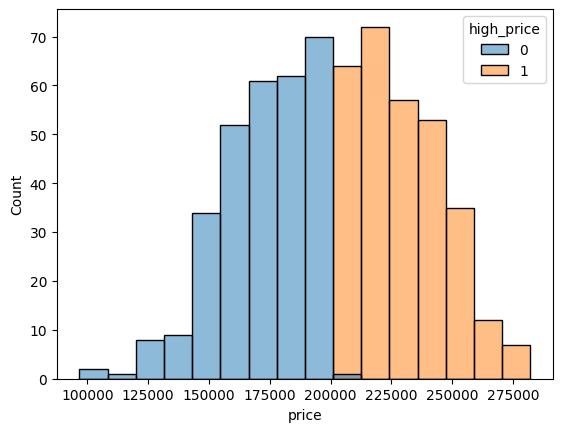

In [5]:
# TODO: Create a histogram of price, colored by high_price
sns.histplot(data= df, x= "price", hue= "high_price")

✏️ **Reflection:** What would separation look like in this plot?

---

## 6. Logistic Regression with statsmodels (R glm → Python)

### R Reference

```r
model_r <- glm(high_price ~ size + neighborhood + type,
               data = df,
               family = binomial)
summary(model_r)
```

### Python Translation


In [6]:
# TODO: Fit a logistic regression using statsmodels
model_sm = smf.logit(formula="high_price ~ size + neighborhood + type", data=df).fit()

Optimization terminated successfully.
         Current function value: 0.686263
         Iterations 4


In [7]:
# TODO: Display the model summary
print(model_sm.summary())

                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  547
Model:                          Logit   Df Residuals:                      538
Method:                           MLE   Df Model:                            8
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                0.009929
Time:                        05:18:37   Log-Likelihood:                -375.39
converged:                       True   LL-Null:                       -379.15
Covariance Type:            nonrobust   LLR p-value:                    0.4807
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.1847      0.287      0.644      0.520      -0.378       0.747
neighborhood[T.Midtown]       -0.3162      0.275     -1.148      0.251      -0.856 

✏️ **Reflection:** Identify two similarities between `summary(model_r)` and `model_sm.summary()`.

---

## 7. Odds Ratios

### R

```r
exp(coef(model_r))
```

### Python

In [ ]:
# TODO: Compute odds ratios from the statsmodels output
odds_ratios = ...
odds_ratios


✏️ **Interpretation:** What does an odds ratio greater than 1 mean?

---

## 8. Predicted Probabilities

In [ ]:
# TODO: Add predicted probabilities to the DataFrame
df["pred_prob"] = ...

In [ ]:
# TODO: Plot the distribution of predicted probabilities

✏️ **Reflection:** Why are probabilities more informative than hard class labels?

---

## 9. Logistic Regression with scikit‑learn (tidymodels → Python)

### tidymodels analogy

* `initial_split()` → `train_test_split()`
* `fit()` → `.fit()`
* `predict(type = "prob")` → `.predict_proba()`

### Python Workflow


In [ ]:
# TODO: Create X and y
X = df[["size"]]
y = df["high_price"]

# TODO: Split into training and test sets
X_train, X_test, y_train, y_test = ...

In [ ]:
# TODO: Fit a scikit-learn logistic regression model
model_sk = ...
model_sk.fit(X_train, y_train)

In [ ]:
# TODO: Generate class predictions and predicted probabilities
y_pred = ...
y_prob = ...

## 10. Model Evaluation


In [ ]:
# TODO: Compute accuracy

In [ ]:
# TODO: Compute confusion matrix

In [ ]:
# TODO: Plot ROC curve and compute AUC

✏️ **Reflection:** Why might AUC be preferred over accuracy?

---

## 11. Comparison Table (Fill In)

| Feature          | R (glm) | R (tidymodels) | statsmodels | scikit‑learn |
| ---------------- | ------- | -------------- | ----------- | ------------ |
| Primary goal     |         |                |             |              |
| Uses formulas    |         |                |             |              |
| Train/test split |         |                |             |              |
| Output           |         |                |             |              |

## 12. Active Learning (15–20 minutes)

**Pair activity:**

1. One student explains logistic regression *using odds*, not probabilities
2. The other explains the difference between statsmodels and scikit‑learn
3. Together, decide which tool you would use for:

   * Policy analysis
   * Price prediction

Be prepared to justify your choices.

## 13. Takeaways

* Logistic regression is the *same model* in R and Python
* Differences are about **workflow and goals**, not mathematics
* statsmodels ≈ `glm`
* scikit‑learn ≈ `tidymodels`
